# Dataset Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1 - Load dataset

In [2]:
def load_images(folder_path):
  """
  Load images from a folder.
  """
  images = []
  for animal in os.listdir(folder_path):
    for race in os.listdir(os.path.join(folder_path, animal)):
      for image in os.listdir(os.path.join(folder_path, animal, race)):
        image_path = os.path.join(folder_path, animal, race, image)
        images.append(image_path)
  return images

In [3]:
image_folder = "../imgDB"
images = load_images(image_folder)

total_images = len(images)
print(f"Total images: {total_images}")

Total images: 4505


# 2 - Répartition des classes

In [21]:
class_names = {}

def extract_class(name):
  """
  Les images sont nommées comme : A_B_animal_race-X où
    A = animal_id
    B = race_id
  L'id de la classe sera: A*6+B
  Ex:
    0_5_araignees_tarantula_795 (5)
    2_2_oiseaux_greatgreyowl_2092 (2*6+2 = 14)
  """
  id = int(name.split("_")[0])*6 + int(name.split("_")[1])
  if id not in class_names:
    class_names[id] = name.split("_")[2] + " " + name.split("_")[3]
  return id

In [31]:
image_classes = [extract_class(os.path.basename(image)) for image in images]
df = pd.DataFrame({
    "image": images,
    "class": image_classes
})

df_class_count = df.groupby("class").size().reset_index(name='count')
df_class_count = df_class_count.sort_values(by="class")
display(df_class_count)

,class,count
0,0,155
1,1,157
2,2,30
3,3,145
4,4,156
5,5,154
6,6,155
7,7,156
8,8,156
9,9,156


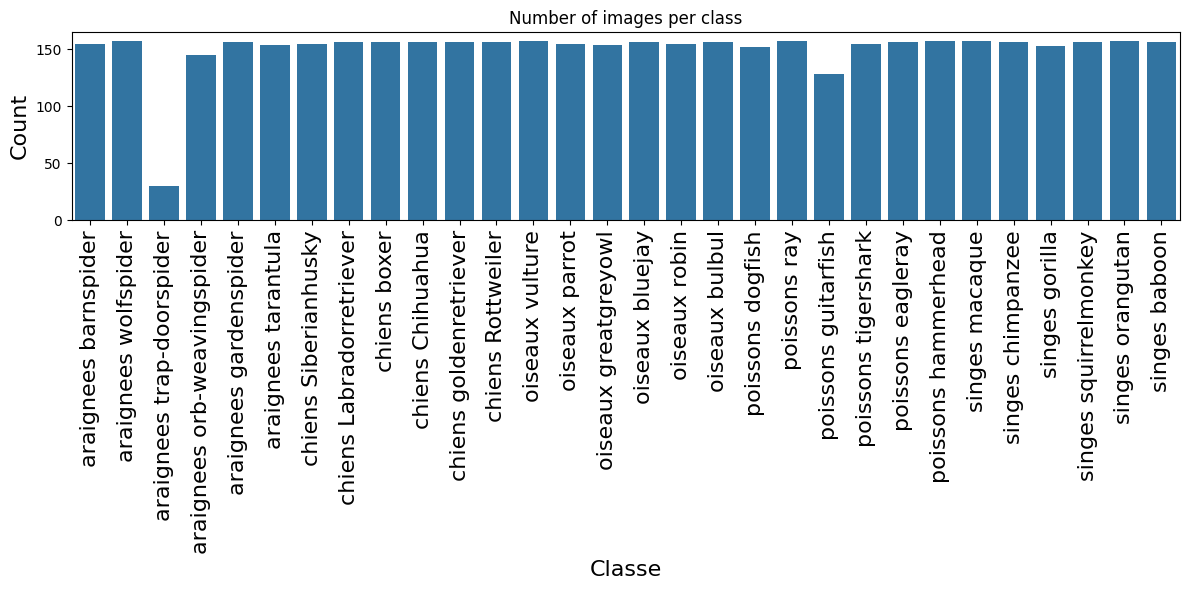

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(x="class", y="count", data=df_class_count)
plt.title("Number of images per class")
plt.xlabel("Classe", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(rotation=90)
plt.xticks(ticks=range(len(df_class_count)), labels=[class_names[id] for id in range(30)], fontsize=16)
plt.tight_layout()
plt.show()